In [ ]:
import os
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from urllib.parse import urljoin
from bs4 import BeautifulSoup

from scipy.signal import butter, filtfilt, iirnotch, welch
from scipy.stats import entropy

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import confusion_matrix, f1_score

In [ ]:
url = "http://brain.bio.msu.ru/eeg_schizophrenia.htm"
save_dir = "/content/eeg_schizophrenia_dataset"
os.makedirs(save_dir, exist_ok=True)

headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

download_links = []

for a in soup.find_all("a", href=True):
    href = a["href"]
    full_url = urljoin(url, href)
    if full_url.lower().endswith(".zip"):
        download_links.append(full_url)

print("Download links:", download_links)

for file_url in download_links:
    filename = os.path.basename(file_url)
    filepath = os.path.join(save_dir, filename)

    r = requests.get(file_url, headers=headers)
    with open(filepath, "wb") as f:
        f.write(r.content)

    print("Downloaded:", filename)

Download links: ['http://brain.bio.msu.ru/eeg_data/schizophrenia/norm.zip', 'http://brain.bio.msu.ru/eeg_data/schizophrenia/sch.zip']
Downloaded: norm.zip
Downloaded: sch.zip


In [ ]:
for file in os.listdir(save_dir):
    if file.lower().endswith(".zip"):
        zip_path = os.path.join(save_dir, file)
        extract_path = os.path.join(save_dir, file.replace(".zip", ""))

        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_path)

        print("Extracted:", file)

Extracted: sch.zip
Extracted: norm.zip


In [ ]:
eea_files = []

for root, dirs, files in os.walk(save_dir):
    for file in files:
        if file.lower().endswith(".eea"):
            eea_files.append(os.path.join(root, file))

print("Total EEA files:", len(eea_files))
print(eea_files[:5])

fs = 128
duration = 60
n_channels = 16
samples_per_channel = fs * duration
expected_values = n_channels * samples_per_channel

X_subjects = []
y_subjects = []
subject_names = []

for file_path in eea_files:
    data = np.loadtxt(file_path)

    if data.size != expected_values:
        print("Skipping:", file_path, data.size)
        continue

    eeg = data.reshape(n_channels, samples_per_channel)
    X_subjects.append(eeg)

    lower_path = file_path.lower()

    if "/sch/" in lower_path:
        y_subjects.append(1)
    elif "/norm/" in lower_path:
        y_subjects.append(0)
    else:
        y_subjects.append(-1)

    subject_names.append(os.path.basename(file_path))

X_subjects = np.array(X_subjects)
y_subjects = np.array(y_subjects)

print("X_subjects shape:", X_subjects.shape)
print("y_subjects shape:", y_subjects.shape)
print("Schizophrenia subjects:", np.sum(y_subjects == 1))
print("Healthy subjects:", np.sum(y_subjects == 0))

Total EEA files: 84
['/content/eeg_schizophrenia_dataset/sch/r416w1.eea', '/content/eeg_schizophrenia_dataset/sch/156w1.eea', '/content/eeg_schizophrenia_dataset/sch/575w1.eea', '/content/eeg_schizophrenia_dataset/sch/586w1.eea', '/content/eeg_schizophrenia_dataset/sch/485w1.eea']
X_subjects shape: (84, 16, 7680)
y_subjects shape: (84,)
Schizophrenia subjects: 45
Healthy subjects: 39


In [ ]:
epoch_duration = 5
epoch_samples = fs * epoch_duration

n_subjects, n_channels, n_samples = X_subjects.shape
n_epochs_per_subject = n_samples // epoch_samples

X_epochs = []
y_epochs = []
groups = []

for subject_idx in range(n_subjects):
    subject_eeg = X_subjects[subject_idx]
    label = y_subjects[subject_idx]

    for ep in range(n_epochs_per_subject):
        start = ep * epoch_samples
        end = start + epoch_samples

        epoch = subject_eeg[:, start:end]

        X_epochs.append(epoch)
        y_epochs.append(label)
        groups.append(subject_idx)

X_epochs = np.array(X_epochs)
y_epochs = np.array(y_epochs)
groups = np.array(groups)

print("X_epochs shape:", X_epochs.shape)
print("y_epochs shape:", y_epochs.shape)
print("groups shape:", groups.shape)
print("Sch epochs:", np.sum(y_epochs == 1))
print("Healthy epochs:", np.sum(y_epochs == 0))

X_epochs shape: (1008, 16, 640)
y_epochs shape: (1008,)
groups shape: (1008,)
Sch epochs: 540
Healthy epochs: 468


In [ ]:
def bandpass_filter(signal, lowcut=0.5, highcut=45, fs=128, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, signal)


def notch_filter(signal, notch_freq=50, fs=128, quality_factor=30):
    nyquist = 0.5 * fs
    freq = notch_freq / nyquist
    b, a = iirnotch(freq, quality_factor)
    return filtfilt(b, a, signal)


def preprocess_epoch(epoch, fs=128):
    filtered_epoch = np.zeros_like(epoch)

    for ch in range(epoch.shape[0]):
        signal = epoch[ch, :]
        signal = bandpass_filter(signal, lowcut=0.5, highcut=45, fs=fs)
        signal = notch_filter(signal, notch_freq=50, fs=fs)
        filtered_epoch[ch, :] = signal

    return filtered_epoch


def time_domain_features(signal):
    return [
        np.mean(signal),
        np.std(signal),
        np.var(signal),
        np.sqrt(np.mean(signal ** 2)),
        np.sum(signal ** 2)
    ]


def hjorth_features(signal):
    first_derivative = np.diff(signal)
    second_derivative = np.diff(first_derivative)

    var_signal = np.var(signal)
    var_first = np.var(first_derivative)
    var_second = np.var(second_derivative)

    activity = var_signal
    mobility = np.sqrt(var_first / var_signal) if var_signal != 0 else 0
    complexity = (np.sqrt(var_second / var_first) / mobility) if var_first != 0 and mobility != 0 else 0

    return [activity, mobility, complexity]


def bandpower_features(signal, fs=128):
    freqs, psd = welch(signal, fs=fs, nperseg=min(256, len(signal)))

    bands = {
        "delta": (0.5, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta": (13, 30),
        "gamma": (30, 45)
    }

    band_powers = []

    for low, high in bands.values():
        idx = np.logical_and(freqs >= low, freqs <= high)
        power = np.trapz(psd[idx], freqs[idx])
        band_powers.append(power)

    total_power = np.trapz(psd, freqs)

    relative_band_powers = [
        power / total_power if total_power != 0 else 0
        for power in band_powers
    ]

    return band_powers + relative_band_powers


def spectral_entropy_feature(signal, fs=128):
    freqs, psd = welch(signal, fs=fs, nperseg=min(256, len(signal)))

    psd_sum = np.sum(psd)

    if psd_sum == 0:
        return 0

    psd_norm = psd / psd_sum
    return entropy(psd_norm)


def extract_advanced_features_from_epoch(epoch, fs=128):
    features = []

    epoch = preprocess_epoch(epoch, fs=fs)

    for ch in range(epoch.shape[0]):
        signal = epoch[ch, :]

        features.extend(time_domain_features(signal))
        features.extend(hjorth_features(signal))
        features.extend(bandpower_features(signal, fs=fs))
        features.append(spectral_entropy_feature(signal, fs=fs))

    return features

In [ ]:
X_advanced_features = []

for i, epoch in enumerate(X_epochs):
    feat = extract_advanced_features_from_epoch(epoch, fs=128)
    X_advanced_features.append(feat)

    if (i + 1) % 100 == 0:
        print("Processed epochs:", i + 1)

X_advanced_features = np.array(X_advanced_features)

print("X_advanced_features shape:", X_advanced_features.shape)
print("y_epochs shape:", y_epochs.shape)
print("groups shape:", groups.shape)

/tmp/ipykernel_1790/3179754818.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  power = np.trapz(psd[idx], freqs[idx])
/tmp/ipykernel_1790/3179754818.py:71: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = np.trapz(psd, freqs)


Processed epochs: 100
Processed epochs: 200
Processed epochs: 300
Processed epochs: 400
Processed epochs: 500
Processed epochs: 600
Processed epochs: 700
Processed epochs: 800
Processed epochs: 900
Processed epochs: 1000
X_advanced_features shape: (1008, 304)
y_epochs shape: (1008,)
groups shape: (1008,)


In [ ]:
pipe_adv = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("svm", SVC(kernel="rbf", C=1, gamma="scale", probability=True))
])

gkf = GroupKFold(n_splits=5)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "sensitivity": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results_adv = cross_validate(
    pipe_adv,
    X_advanced_features,
    y_epochs,
    groups=groups,
    cv=gkf,
    scoring=scoring,
    return_train_score=True
)

for metric in scoring.keys():
    test_scores = results_adv[f"test_{metric}"]
    print(metric, ":", np.mean(test_scores), "+/-", np.std(test_scores))

accuracy : 0.7492647058823529 +/- 0.04497799453411245
precision : 0.7814142678347935 +/- 0.031816334108506955
sensitivity : 0.7407407407407407 +/- 0.12015650516672838
f1 : 0.7553469375358819 +/- 0.059550927326722194
roc_auc : 0.8338348765432098 +/- 0.06871144683073897


In [ ]:
accuracies = []
sensitivities = []
specificities = []
f1_scores = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_advanced_features, y_epochs, groups), 1):

    X_train, X_test = X_advanced_features[train_idx], X_advanced_features[test_idx]
    y_train, y_test = y_epochs[train_idx], y_epochs[test_idx]

    pipe_adv.fit(X_train, y_train)
    y_pred = pipe_adv.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_test, y_pred)

    accuracies.append(acc)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    f1_scores.append(f1)

    print(f"Fold {fold}")
    print("Confusion matrix:")
    print(cm)
    print("Accuracy:", acc)
    print("Sensitivity:", sensitivity)
    print("Specificity:", specificity)
    print("F1:", f1)
    print("-" * 40)

print("Final Advanced Feature Results")
print("Accuracy:", np.mean(accuracies), "+/-", np.std(accuracies))
print("Sensitivity:", np.mean(sensitivities), "+/-", np.std(sensitivities))
print("Specificity:", np.mean(specificities), "+/-", np.std(specificities))
print("F1:", np.mean(f1_scores), "+/-", np.std(f1_scores))

Fold 1
Confusion matrix:
[[70 26]
 [30 78]]
Accuracy: 0.7254901960784313
Sensitivity: 0.7222222222222222
Specificity: 0.7291666666666666
F1: 0.7358490566037735
----------------------------------------
Fold 2
Confusion matrix:
[[76 20]
 [43 65]]
Accuracy: 0.6911764705882353
Sensitivity: 0.6018518518518519
Specificity: 0.7916666666666666
F1: 0.6735751295336787
----------------------------------------
Fold 3
Confusion matrix:
[[ 64  32]
 [  4 104]]
Accuracy: 0.8235294117647058
Sensitivity: 0.9629629629629629
Specificity: 0.6666666666666666
F1: 0.8524590163934426
----------------------------------------
Fold 4
Confusion matrix:
[[76 20]
 [34 74]]
Accuracy: 0.7352941176470589
Sensitivity: 0.6851851851851852
Specificity: 0.7916666666666666
F1: 0.7326732673267327
----------------------------------------
Fold 5
Confusion matrix:
[[69 15]
 [29 79]]
Accuracy: 0.7708333333333334
Sensitivity: 0.7314814814814815
Specificity: 0.8214285714285714
F1: 0.7821782178217822
--------------------------------

IMprovement work

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from collections import Counter
import numpy as np

subject_accuracies = []
subject_sensitivities = []
subject_specificities = []
subject_precisions = []
subject_f1_scores = []
subject_auc_scores = []

all_subject_true = []
all_subject_pred = []
all_subject_prob = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_advanced_features, y_epochs, groups), 1):

    X_train, X_test = X_advanced_features[train_idx], X_advanced_features[test_idx]
    y_train, y_test = y_epochs[train_idx], y_epochs[test_idx]
    groups_train, groups_test = groups[train_idx], groups[test_idx]

    # Train model
    pipe_adv.fit(X_train, y_train)

    # Epoch-level predictions
    y_pred_epoch = pipe_adv.predict(X_test)
    y_prob_epoch = pipe_adv.predict_proba(X_test)[:, 1]

    # Unique test subjects in this fold
    test_subjects = np.unique(groups_test)

    y_true_subject = []
    y_pred_subject = []
    y_prob_subject = []

    for subject in test_subjects:
        subject_mask = groups_test == subject

        # True label for this subject
        true_label = y_test[subject_mask][0]

        # Epoch predictions for this subject
        subject_epoch_preds = y_pred_epoch[subject_mask]
        subject_epoch_probs = y_prob_epoch[subject_mask]

        # Majority voting
        count_0 = np.sum(subject_epoch_preds == 0)
        count_1 = np.sum(subject_epoch_preds == 1)

        if count_1 > count_0:
            final_pred = 1
        else:
            final_pred = 0

        # Average probability for ROC-AUC
        final_prob = np.mean(subject_epoch_probs)

        y_true_subject.append(true_label)
        y_pred_subject.append(final_pred)
        y_prob_subject.append(final_prob)

    y_true_subject = np.array(y_true_subject)
    y_pred_subject = np.array(y_pred_subject)
    y_prob_subject = np.array(y_prob_subject)

    cm = confusion_matrix(y_true_subject, y_pred_subject)
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_true_subject, y_pred_subject)
    precision = precision_score(y_true_subject, y_pred_subject)
    sensitivity = recall_score(y_true_subject, y_pred_subject)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_true_subject, y_pred_subject)

    try:
        auc = roc_auc_score(y_true_subject, y_prob_subject)
    except:
        auc = np.nan

    subject_accuracies.append(acc)
    subject_precisions.append(precision)
    subject_sensitivities.append(sensitivity)
    subject_specificities.append(specificity)
    subject_f1_scores.append(f1)
    subject_auc_scores.append(auc)

    all_subject_true.extend(y_true_subject)
    all_subject_pred.extend(y_pred_subject)
    all_subject_prob.extend(y_prob_subject)

    print(f"Fold {fold}")
    print("Test subjects:", len(test_subjects))
    print("Confusion matrix:")
    print(cm)
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Sensitivity:", sensitivity)
    print("Specificity:", specificity)
    print("F1:", f1)
    print("ROC-AUC:", auc)
    print("-" * 40)

print("Final Subject-Level Majority Voting Results")
print("Accuracy:", np.mean(subject_accuracies), "+/-", np.std(subject_accuracies))
print("Precision:", np.mean(subject_precisions), "+/-", np.std(subject_precisions))
print("Sensitivity:", np.mean(subject_sensitivities), "+/-", np.std(subject_sensitivities))
print("Specificity:", np.mean(subject_specificities), "+/-", np.std(subject_specificities))
print("F1:", np.mean(subject_f1_scores), "+/-", np.std(subject_f1_scores))
print("ROC-AUC:", np.nanmean(subject_auc_scores), "+/-", np.nanstd(subject_auc_scores))

Fold 1
Test subjects: 17
Confusion matrix:
[[7 1]
 [3 6]]
Accuracy: 0.7647058823529411
Precision: 0.8571428571428571
Sensitivity: 0.6666666666666666
Specificity: 0.875
F1: 0.75
ROC-AUC: 0.875
----------------------------------------
Fold 2
Test subjects: 17
Confusion matrix:
[[7 1]
 [3 6]]
Accuracy: 0.7647058823529411
Precision: 0.8571428571428571
Sensitivity: 0.6666666666666666
Specificity: 0.875
F1: 0.75
ROC-AUC: 0.8055555555555556
----------------------------------------
Fold 3
Test subjects: 17
Confusion matrix:
[[6 2]
 [0 9]]
Accuracy: 0.8823529411764706
Precision: 0.8181818181818182
Sensitivity: 1.0
Specificity: 0.75
F1: 0.9
ROC-AUC: 1.0
----------------------------------------
Fold 4
Test subjects: 17
Confusion matrix:
[[7 1]
 [3 6]]
Accuracy: 0.7647058823529411
Precision: 0.8571428571428571
Sensitivity: 0.6666666666666666
Specificity: 0.875
F1: 0.75
ROC-AUC: 0.8472222222222222
----------------------------------------
Fold 5
Test subjects: 16
Confusion matrix:
[[6 1]
 [2 7]]
Acc

next improvement

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import GroupKFold

pipe_tune = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("svm", SVC(kernel="rbf", probability=True))
])

param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.01, 0.001, 0.0001]
}

gkf = GroupKFold(n_splits=5)

grid = GridSearchCV(
    pipe_tune,
    param_grid,
    cv=gkf,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_advanced_features, y_epochs, groups=groups)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'svm__C': 10, 'svm__gamma': 'scale'}
Best CV F1: 0.7598293784745573


In [ ]:
best_pipe = grid.best_estimator_

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

subject_accuracies = []
subject_sensitivities = []
subject_specificities = []
subject_precisions = []
subject_f1_scores = []
subject_auc_scores = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_advanced_features, y_epochs, groups), 1):

    X_train, X_test = X_advanced_features[train_idx], X_advanced_features[test_idx]
    y_train, y_test = y_epochs[train_idx], y_epochs[test_idx]
    groups_test = groups[test_idx]

    # Train tuned model
    best_pipe.fit(X_train, y_train)

    # Epoch-level predictions
    y_pred_epoch = best_pipe.predict(X_test)
    y_prob_epoch = best_pipe.predict_proba(X_test)[:, 1]

    # Subject-level majority voting
    test_subjects = np.unique(groups_test)

    y_true_subject = []
    y_pred_subject = []
    y_prob_subject = []

    for subject in test_subjects:
        subject_mask = groups_test == subject

        true_label = y_test[subject_mask][0]
        subject_epoch_preds = y_pred_epoch[subject_mask]
        subject_epoch_probs = y_prob_epoch[subject_mask]

        count_0 = np.sum(subject_epoch_preds == 0)
        count_1 = np.sum(subject_epoch_preds == 1)

        final_pred = 1 if count_1 > count_0 else 0
        final_prob = np.mean(subject_epoch_probs)

        y_true_subject.append(true_label)
        y_pred_subject.append(final_pred)
        y_prob_subject.append(final_prob)

    y_true_subject = np.array(y_true_subject)
    y_pred_subject = np.array(y_pred_subject)
    y_prob_subject = np.array(y_prob_subject)

    cm = confusion_matrix(y_true_subject, y_pred_subject)
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_true_subject, y_pred_subject)
    precision = precision_score(y_true_subject, y_pred_subject)
    sensitivity = recall_score(y_true_subject, y_pred_subject)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_true_subject, y_pred_subject)
    auc = roc_auc_score(y_true_subject, y_prob_subject)

    subject_accuracies.append(acc)
    subject_precisions.append(precision)
    subject_sensitivities.append(sensitivity)
    subject_specificities.append(specificity)
    subject_f1_scores.append(f1)
    subject_auc_scores.append(auc)

    print(f"Fold {fold}")
    print("Confusion matrix:")
    print(cm)
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Sensitivity:", sensitivity)
    print("Specificity:", specificity)
    print("F1:", f1)
    print("ROC-AUC:", auc)
    print("-" * 40)

print("Final Tuned SVM Subject-Level Results")
print("Accuracy:", np.mean(subject_accuracies), "+/-", np.std(subject_accuracies))
print("Precision:", np.mean(subject_precisions), "+/-", np.std(subject_precisions))
print("Sensitivity:", np.mean(subject_sensitivities), "+/-", np.std(subject_sensitivities))
print("Specificity:", np.mean(subject_specificities), "+/-", np.std(subject_specificities))
print("F1:", np.mean(subject_f1_scores), "+/-", np.std(subject_f1_scores))
print("ROC-AUC:", np.mean(subject_auc_scores), "+/-", np.std(subject_auc_scores))

Fold 1
Confusion matrix:
[[7 1]
 [3 6]]
Accuracy: 0.7647058823529411
Precision: 0.8571428571428571
Sensitivity: 0.6666666666666666
Specificity: 0.875
F1: 0.75
ROC-AUC: 0.861111111111111
----------------------------------------
Fold 2
Confusion matrix:
[[7 1]
 [3 6]]
Accuracy: 0.7647058823529411
Precision: 0.8571428571428571
Sensitivity: 0.6666666666666666
Specificity: 0.875
F1: 0.75
ROC-AUC: 0.8055555555555556
----------------------------------------
Fold 3
Confusion matrix:
[[5 3]
 [0 9]]
Accuracy: 0.8235294117647058
Precision: 0.75
Sensitivity: 1.0
Specificity: 0.625
F1: 0.8571428571428571
ROC-AUC: 0.9722222222222222
----------------------------------------
Fold 4
Confusion matrix:
[[6 2]
 [3 6]]
Accuracy: 0.7058823529411765
Precision: 0.75
Sensitivity: 0.6666666666666666
Specificity: 0.75
F1: 0.7058823529411765
ROC-AUC: 0.8333333333333333
----------------------------------------
Fold 5
Confusion matrix:
[[6 1]
 [2 7]]
Accuracy: 0.8125
Precision: 0.875
Sensitivity: 0.7777777777777778

phr improvement

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import pandas as pd

models = {
    "SVM": SVC(kernel="rbf", C=1, gamma="scale", probability=True),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

gkf = GroupKFold(n_splits=5)

final_results = []

for model_name, model in models.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("clf", model)
    ])

    accs = []
    sens = []
    specs = []
    f1s = []
    aucs = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_advanced_features, y_epochs, groups), 1):

        X_train, X_test = X_advanced_features[train_idx], X_advanced_features[test_idx]
        y_train, y_test = y_epochs[train_idx], y_epochs[test_idx]
        groups_test = groups[test_idx]

        pipe.fit(X_train, y_train)

        y_pred_epoch = pipe.predict(X_test)

        if hasattr(pipe, "predict_proba"):
            y_prob_epoch = pipe.predict_proba(X_test)[:, 1]
        else:
            y_prob_epoch = y_pred_epoch

        test_subjects = np.unique(groups_test)

        y_true_subject = []
        y_pred_subject = []
        y_prob_subject = []

        for subject in test_subjects:
            mask = groups_test == subject

            true_label = y_test[mask][0]
            subject_preds = y_pred_epoch[mask]
            subject_probs = y_prob_epoch[mask]

            count_0 = np.sum(subject_preds == 0)
            count_1 = np.sum(subject_preds == 1)

            final_pred = 1 if count_1 > count_0 else 0
            final_prob = np.mean(subject_probs)

            y_true_subject.append(true_label)
            y_pred_subject.append(final_pred)
            y_prob_subject.append(final_prob)

        y_true_subject = np.array(y_true_subject)
        y_pred_subject = np.array(y_pred_subject)
        y_prob_subject = np.array(y_prob_subject)

        cm = confusion_matrix(y_true_subject, y_pred_subject)
        tn, fp, fn, tp = cm.ravel()

        acc = accuracy_score(y_true_subject, y_pred_subject)
        sensitivity = recall_score(y_true_subject, y_pred_subject)
        specificity = tn / (tn + fp)
        f1 = f1_score(y_true_subject, y_pred_subject)

        try:
            auc = roc_auc_score(y_true_subject, y_prob_subject)
        except:
            auc = np.nan

        accs.append(acc)
        sens.append(sensitivity)
        specs.append(specificity)
        f1s.append(f1)
        aucs.append(auc)

    final_results.append({
        "Model": model_name,
        "Accuracy_mean": np.mean(accs),
        "Accuracy_std": np.std(accs),
        "Sensitivity_mean": np.mean(sens),
        "Specificity_mean": np.mean(specs),
        "F1_mean": np.mean(f1s),
        "ROC_AUC_mean": np.nanmean(aucs)
    })

results_df = pd.DataFrame(final_results)
results_df

,Model,Accuracy_mean,Accuracy_std,Sensitivity_mean,Specificity_mean,F1_mean,ROC_AUC_mean
0,SVM,0.797794,0.046154,0.755556,0.846429,0.794706,0.892857
1,Logistic Regression,0.810294,0.041698,0.777778,0.846429,0.810905,0.836508
2,Random Forest,0.785294,0.080869,0.777778,0.796429,0.794100,0.886905
3,KNN,0.761765,0.111765,0.622222,0.925000,0.723400,0.874008


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

best_lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("clf", LogisticRegression(max_iter=1000))
])

gkf = GroupKFold(n_splits=5)

accs = []
precisions = []
sensitivities = []
specificities = []
f1s = []
aucs = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_advanced_features, y_epochs, groups), 1):

    X_train, X_test = X_advanced_features[train_idx], X_advanced_features[test_idx]
    y_train, y_test = y_epochs[train_idx], y_epochs[test_idx]
    groups_test = groups[test_idx]

    best_lr_pipe.fit(X_train, y_train)

    y_pred_epoch = best_lr_pipe.predict(X_test)
    y_prob_epoch = best_lr_pipe.predict_proba(X_test)[:, 1]

    test_subjects = np.unique(groups_test)

    y_true_subject = []
    y_pred_subject = []
    y_prob_subject = []

    for subject in test_subjects:
        mask = groups_test == subject

        true_label = y_test[mask][0]
        subject_preds = y_pred_epoch[mask]
        subject_probs = y_prob_epoch[mask]

        count_0 = np.sum(subject_preds == 0)
        count_1 = np.sum(subject_preds == 1)

        final_pred = 1 if count_1 > count_0 else 0
        final_prob = np.mean(subject_probs)

        y_true_subject.append(true_label)
        y_pred_subject.append(final_pred)
        y_prob_subject.append(final_prob)

    y_true_subject = np.array(y_true_subject)
    y_pred_subject = np.array(y_pred_subject)
    y_prob_subject = np.array(y_prob_subject)

    cm = confusion_matrix(y_true_subject, y_pred_subject)
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_true_subject, y_pred_subject)
    precision = precision_score(y_true_subject, y_pred_subject)
    sensitivity = recall_score(y_true_subject, y_pred_subject)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_true_subject, y_pred_subject)
    auc = roc_auc_score(y_true_subject, y_prob_subject)

    accs.append(acc)
    precisions.append(precision)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    f1s.append(f1)
    aucs.append(auc)

    print(f"Fold {fold}")
    print("Confusion matrix:")
    print(cm)
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Sensitivity:", sensitivity)
    print("Specificity:", specificity)
    print("F1:", f1)
    print("ROC-AUC:", auc)
    print("-" * 40)

print("Final Logistic Regression Subject-Level Results")
print("Accuracy:", np.mean(accs), "+/-", np.std(accs))
print("Precision:", np.mean(precisions), "+/-", np.std(precisions))
print("Sensitivity:", np.mean(sensitivities), "+/-", np.std(sensitivities))
print("Specificity:", np.mean(specificities), "+/-", np.std(specificities))
print("F1:", np.mean(f1s), "+/-", np.std(f1s))
print("ROC-AUC:", np.mean(aucs), "+/-", np.std(aucs))

Fold 1
Confusion matrix:
[[7 1]
 [3 6]]
Accuracy: 0.7647058823529411
Precision: 0.8571428571428571
Sensitivity: 0.6666666666666666
Specificity: 0.875
F1: 0.75
ROC-AUC: 0.75
----------------------------------------
Fold 2
Confusion matrix:
[[7 1]
 [3 6]]
Accuracy: 0.7647058823529411
Precision: 0.8571428571428571
Sensitivity: 0.6666666666666666
Specificity: 0.875
F1: 0.75
ROC-AUC: 0.8472222222222222
----------------------------------------
Fold 3
Confusion matrix:
[[6 2]
 [1 8]]
Accuracy: 0.8235294117647058
Precision: 0.8
Sensitivity: 0.8888888888888888
Specificity: 0.75
F1: 0.8421052631578947
ROC-AUC: 0.8611111111111112
----------------------------------------
Fold 4
Confusion matrix:
[[7 1]
 [2 7]]
Accuracy: 0.8235294117647058
Precision: 0.875
Sensitivity: 0.7777777777777778
Specificity: 0.875
F1: 0.8235294117647058
ROC-AUC: 0.8194444444444444
----------------------------------------
Fold 5
Confusion matrix:
[[6 1]
 [1 8]]
Accuracy: 0.875
Precision: 0.8888888888888888
Sensitivity: 0.88

WINDOW division code

In [ ]:
def create_epochs_for_window(X_subjects, y_subjects, window_sec, fs=128):
    """
    X_subjects shape = subjects × channels × samples
    y_subjects shape = subjects
    window_sec = epoch/window length in seconds
    """

    window_samples = int(window_sec * fs)

    n_subjects, n_channels, n_samples = X_subjects.shape
    n_epochs_per_subject = n_samples // window_samples

    X_epochs = []
    y_epochs = []
    groups = []

    for subject_idx in range(n_subjects):
        subject_eeg = X_subjects[subject_idx]
        label = y_subjects[subject_idx]

        for ep in range(n_epochs_per_subject):
            start = ep * window_samples
            end = start + window_samples

            epoch = subject_eeg[:, start:end]

            X_epochs.append(epoch)
            y_epochs.append(label)
            groups.append(subject_idx)

    X_epochs = np.array(X_epochs)
    y_epochs = np.array(y_epochs)
    groups = np.array(groups)

    return X_epochs, y_epochs, groups

In [ ]:
def extract_features_for_epochs(X_epochs, fs=128):
    X_features = []

    for i, epoch in enumerate(X_epochs):
        feat = extract_advanced_features_from_epoch(epoch, fs=fs)
        X_features.append(feat)

        if (i + 1) % 500 == 0:
            print("Processed epochs:", i + 1)

    X_features = np.array(X_features)
    return X_features

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

def evaluate_subject_level_logistic_regression(X_features, y_epochs, groups):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("clf", LogisticRegression(max_iter=1000))
    ])

    gkf = GroupKFold(n_splits=5)

    accs = []
    precisions = []
    sensitivities = []
    specificities = []
    f1s = []
    aucs = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_features, y_epochs, groups), 1):

        X_train, X_test = X_features[train_idx], X_features[test_idx]
        y_train, y_test = y_epochs[train_idx], y_epochs[test_idx]
        groups_test = groups[test_idx]

        pipe.fit(X_train, y_train)

        y_pred_epoch = pipe.predict(X_test)
        y_prob_epoch = pipe.predict_proba(X_test)[:, 1]

        test_subjects = np.unique(groups_test)

        y_true_subject = []
        y_pred_subject = []
        y_prob_subject = []

        for subject in test_subjects:
            mask = groups_test == subject

            true_label = y_test[mask][0]
            subject_preds = y_pred_epoch[mask]
            subject_probs = y_prob_epoch[mask]

            count_0 = np.sum(subject_preds == 0)
            count_1 = np.sum(subject_preds == 1)

            final_pred = 1 if count_1 > count_0 else 0
            final_prob = np.mean(subject_probs)

            y_true_subject.append(true_label)
            y_pred_subject.append(final_pred)
            y_prob_subject.append(final_prob)

        y_true_subject = np.array(y_true_subject)
        y_pred_subject = np.array(y_pred_subject)
        y_prob_subject = np.array(y_prob_subject)

        cm = confusion_matrix(y_true_subject, y_pred_subject)
        tn, fp, fn, tp = cm.ravel()

        acc = accuracy_score(y_true_subject, y_pred_subject)
        precision = precision_score(y_true_subject, y_pred_subject, zero_division=0)
        sensitivity = recall_score(y_true_subject, y_pred_subject, zero_division=0)
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
        f1 = f1_score(y_true_subject, y_pred_subject, zero_division=0)

        try:
            auc = roc_auc_score(y_true_subject, y_prob_subject)
        except:
            auc = np.nan

        accs.append(acc)
        precisions.append(precision)
        sensitivities.append(sensitivity)
        specificities.append(specificity)
        f1s.append(f1)
        aucs.append(auc)

    return {
        "Accuracy_mean": np.mean(accs),
        "Accuracy_std": np.std(accs),
        "Precision_mean": np.mean(precisions),
        "Sensitivity_mean": np.mean(sensitivities),
        "Specificity_mean": np.mean(specificities),
        "F1_mean": np.mean(f1s),
        "ROC_AUC_mean": np.nanmean(aucs)
    }

In [ ]:
window_lengths = [1, 2, 5, 10, 60]

window_results = []

for window_sec in window_lengths:
    print("=" * 60)
    print("Running window:", window_sec, "sec")

    X_epochs_w, y_epochs_w, groups_w = create_epochs_for_window(
        X_subjects,
        y_subjects,
        window_sec=window_sec,
        fs=128
    )

    print("X_epochs shape:", X_epochs_w.shape)
    print("y_epochs shape:", y_epochs_w.shape)
    print("groups shape:", groups_w.shape)

    X_features_w = extract_features_for_epochs(X_epochs_w, fs=128)

    print("X_features shape:", X_features_w.shape)

    result = evaluate_subject_level_logistic_regression(
        X_features_w,
        y_epochs_w,
        groups_w
    )

    result["Window_sec"] = window_sec
    result["Total_epochs"] = X_epochs_w.shape[0]
    result["Features"] = X_features_w.shape[1]

    window_results.append(result)

    print("Result:")
    print(result)

window_results_df = pd.DataFrame(window_results)

window_results_df = window_results_df[
    [
        "Window_sec",
        "Total_epochs",
        "Features",
        "Accuracy_mean",
        "Accuracy_std",
        "Precision_mean",
        "Sensitivity_mean",
        "Specificity_mean",
        "F1_mean",
        "ROC_AUC_mean"
    ]
]

window_results_df

Running window: 1 sec
X_epochs shape: (5040, 16, 128)
y_epochs shape: (5040,)
groups shape: (5040,)


/tmp/ipykernel_1790/3179754818.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  power = np.trapz(psd[idx], freqs[idx])
/tmp/ipykernel_1790/3179754818.py:71: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = np.trapz(psd, freqs)


Processed epochs: 500
Processed epochs: 1000
Processed epochs: 1500
Processed epochs: 2000
Processed epochs: 2500
Processed epochs: 3000
Processed epochs: 3500
Processed epochs: 4000
Processed epochs: 4500
Processed epochs: 5000
X_features shape: (5040, 304)
Result:
{'Accuracy_mean': np.float64(0.775), 'Accuracy_std': np.float64(0.06635596572163809), 'Precision_mean': np.float64(0.8017316017316019), 'Sensitivity_mean': np.float64(0.7777777777777778), 'Specificity_mean': np.float64(0.7678571428571429), 'F1_mean': np.float64(0.7791228070175438), 'ROC_AUC_mean': np.float64(0.8238095238095238), 'Window_sec': 1, 'Total_epochs': 5040, 'Features': 304}
Running window: 2 sec
X_epochs shape: (2520, 16, 256)
y_epochs shape: (2520,)
groups shape: (2520,)


/tmp/ipykernel_1790/3179754818.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  power = np.trapz(psd[idx], freqs[idx])
/tmp/ipykernel_1790/3179754818.py:71: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = np.trapz(psd, freqs)


Processed epochs: 500
Processed epochs: 1000
Processed epochs: 1500
Processed epochs: 2000
Processed epochs: 2500
X_features shape: (2520, 304)
Result:
{'Accuracy_mean': np.float64(0.7867647058823529), 'Accuracy_std': np.float64(0.057710049618672286), 'Precision_mean': np.float64(0.8055194805194805), 'Sensitivity_mean': np.float64(0.8), 'Specificity_mean': np.float64(0.7678571428571429), 'F1_mean': np.float64(0.7958823529411764), 'ROC_AUC_mean': np.float64(0.8492063492063491), 'Window_sec': 2, 'Total_epochs': 2520, 'Features': 304}
Running window: 5 sec
X_epochs shape: (1008, 16, 640)
y_epochs shape: (1008,)
groups shape: (1008,)


...

/tmp/ipykernel_1790/3179754818.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  power = np.trapz(psd[idx], freqs[idx])
/tmp/ipykernel_1790/3179754818.py:71: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = np.trapz(psd, freqs)


Processed epochs: 500
X_features shape: (504, 304)
Result:
{'Accuracy_mean': np.float64(0.7375), 'Accuracy_std': np.float64(0.03382352941176467), 'Precision_mean': np.float64(0.7942857142857143), 'Sensitivity_mean': np.float64(0.711111111111111), 'Specificity_mean': np.float64(0.7642857142857142), 'F1_mean': np.float64(0.7447368421052631), 'ROC_AUC_mean': np.float64(0.8011904761904761), 'Window_sec': 10, 'Total_epochs': 504, 'Features': 304}
Running window: 60 sec
X_epochs shape: (84, 16, 7680)
y_epochs shape: (84,)
groups shape: (84,)


/tmp/ipykernel_1790/3179754818.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  power = np.trapz(psd[idx], freqs[idx])
/tmp/ipykernel_1790/3179754818.py:71: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = np.trapz(psd, freqs)


X_features shape: (84, 304)
Result:
{'Accuracy_mean': np.float64(0.6661764705882354), 'Accuracy_std': np.float64(0.05000000000000002), 'Precision_mean': np.float64(0.707857142857143), 'Sensitivity_mean': np.float64(0.6666666666666666), 'Specificity_mean': np.float64(0.6678571428571429), 'F1_mean': np.float64(0.6757297655904467), 'ROC_AUC_mean': np.float64(0.7547619047619047), 'Window_sec': 60, 'Total_epochs': 84, 'Features': 304}


,Window_sec,Total_epochs,Features,Accuracy_mean,Accuracy_std,Precision_mean,Sensitivity_mean,Specificity_mean,F1_mean,ROC_AUC_mean
0,1,5040,304,0.775000,0.066356,0.801732,0.777778,0.767857,0.779123,0.823810
1,2,2520,304,0.786765,0.057710,0.805519,0.800000,0.767857,0.795882,0.849206
2,5,1008,304,0.810294,0.041698,0.855635,0.777778,0.846429,0.810905,0.836508
3,10,504,304,0.737500,0.033824,0.794286,0.711111,0.764286,0.744737,0.801190
4,60,84,304,0.666176,0.050000,0.707857,0.666667,0.667857,0.675730,0.754762


In [ ]:
window_results_percent = window_results_df.copy()

metric_cols = [
    "Accuracy_mean",
    "Accuracy_std",
    "Precision_mean",
    "Sensitivity_mean",
    "Specificity_mean",
    "F1_mean",
    "ROC_AUC_mean"
]

for col in metric_cols:
    window_results_percent[col] = window_results_percent[col] * 100

window_results_percent

,Window_sec,Total_epochs,Features,Accuracy_mean,Accuracy_std,Precision_mean,Sensitivity_mean,Specificity_mean,F1_mean,ROC_AUC_mean
0,1,5040,304,77.500000,6.635597,80.173160,77.777778,76.785714,77.912281,82.380952
1,2,2520,304,78.676471,5.771005,80.551948,80.000000,76.785714,79.588235,84.920635
2,5,1008,304,81.029412,4.169837,85.563492,77.777778,84.642857,81.090471,83.650794
3,10,504,304,73.750000,3.382353,79.428571,71.111111,76.428571,74.473684,80.119048
4,60,84,304,66.617647,5.000000,70.785714,66.666667,66.785714,67.572977,75.476190


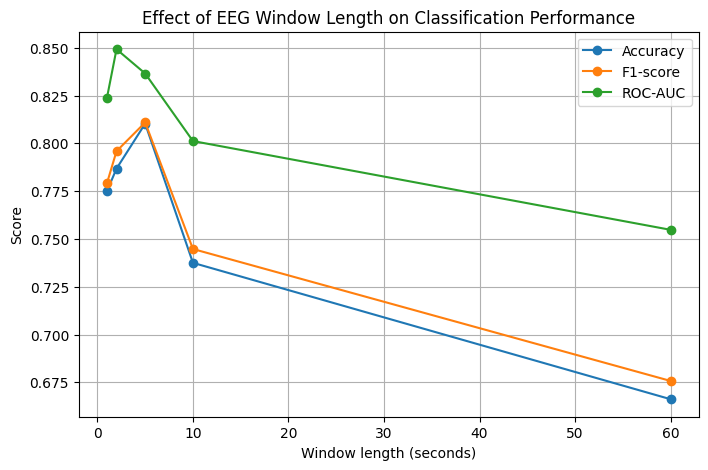

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(window_results_df["Window_sec"], window_results_df["Accuracy_mean"], marker="o", label="Accuracy")
plt.plot(window_results_df["Window_sec"], window_results_df["F1_mean"], marker="o", label="F1-score")
plt.plot(window_results_df["Window_sec"], window_results_df["ROC_AUC_mean"], marker="o", label="ROC-AUC")

plt.xlabel("Window length (seconds)")
plt.ylabel("Score")
plt.title("Effect of EEG Window Length on Classification Performance")
plt.legend()
plt.grid(True)
plt.show()

AB NEXT IMPROVEMNT

In [ ]:
channel_names = [
    "F7", "F3", "F4", "F8",
    "T3", "C3", "Cz", "C4",
    "T4", "T5", "P3", "Pz",
    "P4", "T6", "O1", "O2"
]

feature_types = [
    "mean", "std", "var", "rms", "energy",
    "hjorth_activity", "hjorth_mobility", "hjorth_complexity",
    "delta_power", "theta_power", "alpha_power", "beta_power", "gamma_power",
    "delta_relative", "theta_relative", "alpha_relative", "beta_relative", "gamma_relative",
    "spectral_entropy"
]

advanced_feature_names = []

for ch in channel_names:
    for ft in feature_types:
        advanced_feature_names.append(f"{ch}_{ft}")

print("Total feature names:", len(advanced_feature_names))
print(advanced_feature_names[:20])

Total feature names: 304
['F7_mean', 'F7_std', 'F7_var', 'F7_rms', 'F7_energy', 'F7_hjorth_activity', 'F7_hjorth_mobility', 'F7_hjorth_complexity', 'F7_delta_power', 'F7_theta_power', 'F7_alpha_power', 'F7_beta_power', 'F7_gamma_power', 'F7_delta_relative', 'F7_theta_relative', 'F7_alpha_relative', 'F7_beta_relative', 'F7_gamma_relative', 'F7_spectral_entropy', 'F3_mean']


In [ ]:
feature_groups = {
    "Time-domain": ["mean", "std", "var", "rms", "energy"],
    "Hjorth": ["hjorth_activity", "hjorth_mobility", "hjorth_complexity"],
    "Band power": ["delta_power", "theta_power", "alpha_power", "beta_power", "gamma_power"],
    "Relative band power": ["delta_relative", "theta_relative", "alpha_relative", "beta_relative", "gamma_relative"],
    "Spectral entropy": ["spectral_entropy"],
    "All features": feature_types
}

group_indices = {}

for group_name, selected_features in feature_groups.items():
    indices = []

    for i, fname in enumerate(advanced_feature_names):
        for sf in selected_features:
            if fname.endswith(sf):
                indices.append(i)

    group_indices[group_name] = indices

for group_name, indices in group_indices.items():
    print(group_name, ":", len(indices), "features")

Time-domain : 80 features
Hjorth : 48 features
Band power : 80 features
Relative band power : 80 features
Spectral entropy : 16 features
All features : 304 features


In [ ]:
feature_group_results = []

for group_name, indices in group_indices.items():

    print("=" * 60)
    print("Evaluating:", group_name)

    X_group = X_advanced_features[:, indices]

    result = evaluate_subject_level_logistic_regression(
        X_group,
        y_epochs,
        groups
    )

    result["Feature_group"] = group_name
    result["Num_features"] = X_group.shape[1]

    feature_group_results.append(result)

    print(result)

feature_group_results_df = pd.DataFrame(feature_group_results)

feature_group_results_df = feature_group_results_df[
    [
        "Feature_group",
        "Num_features",
        "Accuracy_mean",
        "Accuracy_std",
        "Precision_mean",
        "Sensitivity_mean",
        "Specificity_mean",
        "F1_mean",
        "ROC_AUC_mean"
    ]
]

feature_group_results_df

Evaluating: Time-domain
{'Accuracy_mean': np.float64(0.7007352941176471), 'Accuracy_std': np.float64(0.18207402768405334), 'Precision_mean': np.float64(0.6927777777777778), 'Sensitivity_mean': np.float64(0.711111111111111), 'Specificity_mean': np.float64(0.6892857142857143), 'F1_mean': np.float64(0.6924173178043147), 'ROC_AUC_mean': np.float64(0.7472222222222222), 'Feature_group': 'Time-domain', 'Num_features': 80}
Evaluating: Hjorth
{'Accuracy_mean': np.float64(0.7382352941176471), 'Accuracy_std': np.float64(0.0791389649827865), 'Precision_mean': np.float64(0.7825396825396825), 'Sensitivity_mean': np.float64(0.711111111111111), 'Specificity_mean': np.float64(0.7678571428571429), 'F1_mean': np.float64(0.7434640522875817), 'ROC_AUC_mean': np.float64(0.7825396825396825), 'Feature_group': 'Hjorth', 'Num_features': 48}
Evaluating: Band power
{'Accuracy_mean': np.float64(0.7029411764705882), 'Accuracy_std': np.float64(0.04956558690103738), 'Precision_mean': np.float64(0.7337662337662337), '

,Feature_group,Num_features,Accuracy_mean,Accuracy_std,Precision_mean,Sensitivity_mean,Specificity_mean,F1_mean,ROC_AUC_mean
0,Time-domain,80,0.700735,0.182074,0.692778,0.711111,0.689286,0.692417,0.747222
1,Hjorth,48,0.738235,0.079139,0.782540,0.711111,0.767857,0.743464,0.782540
2,Band power,80,0.702941,0.049566,0.733766,0.711111,0.689286,0.711667,0.791667
3,Relative band power,80,0.701471,0.068914,0.734524,0.711111,0.692857,0.716597,0.765079
4,Spectral entropy,16,0.738235,0.087447,0.755556,0.755556,0.717857,0.755556,0.781746
5,All features,304,0.810294,0.041698,0.855635,0.777778,0.846429,0.810905,0.836508


In [ ]:
feature_group_percent = feature_group_results_df.copy()

metric_cols = [
    "Accuracy_mean",
    "Accuracy_std",
    "Precision_mean",
    "Sensitivity_mean",
    "Specificity_mean",
    "F1_mean",
    "ROC_AUC_mean"
]

for col in metric_cols:
    feature_group_percent[col] = feature_group_percent[col] * 100

feature_group_percent

ye pahle k h